### QICK Standard ZCU111 Firmware + FFT/Spectrum Analysis

This firmware is a standard ZCU111 firmware (with less SGv6 though to make room for the BREAD Small logic) + BREAD Small chain. 
The BREAD small chain is a reduced FFT version (16k in place of 32k points) of the BREAD Real project.

BREAD Small part: this part has one input ADC and one output DAC. ADC is connected to Tile 224 Channel 0. DAC is connected to Tile 229 Channel 2.

There's an option to connect ADC_224_0 to a Readout path to capture data with the tProcessor.

See examples to extract data from the different points.

<!-- ![alt text](images/std_111_bread_small.png "Block Diagram") -->
<!-- ![alt text](images/qick_tprocv2_111_fft_spectrum_diagram.png "Block Diagram") -->
<img src="images/qick_diagrams-QICK_TPROCV2_111_FFT_SPECTRUM.drawio.png" alt="Placeholder" width="1200" height="1000">


# FFT spectrum firmware data analysis
This part of the notebook analyzes the data obtained at the **ACCUMULATOR_1** core in the diagram above.

System description:

- ADC resolution: 12 bits (signed)
- Full-scale (FS) amplitude = 2^(11) = 2048
- Sampling rate Fs = 32 MHz
- FFT size N = 65536
- FFT has NO internal scaling
- FFT IP outputs averaged power per bin:

\begin{equation}
    P[k] = average( |X[k]|^2 )
  \end{equation}

- Signal is complex (IQ)
- Tone has been digitally mixed to DC

## Important Notice
Since the 12-bit data in the RFSoC ADC is MSB-aligned in a 16-bit register, the data is essentially shifted left by 4 bits ($16 - 12 = 4$).

---

### 1. The Mapping Physics

In the FPGA registers, the 12-bit signed ADC value ($D_{12}$) relates to the 16-bit value ($D_{16}$) as follows:

$$D_{16} = D_{12} \times 2^4 = D_{12} \times 16$$

### 2. Impact on the System Parameters

Because of this alignment, the values entering the FFT are 16 times larger than the "native" 12-bit ADC counts. We need to update the reference values:

* **Effective Full-Scale (FS):** Instead of $2^{11}$, the FPGA logic sees $2^{11} \times 2^4 = 2^{15} = 32,768$.
* **Bit Growth in FFT:** Since the FFT (the IP from AMD) has **no internal scaling**, the output magnitude grows by a factor of $N$ (65,536).
* **Power Calculation:** Since power is proportional to the square of the amplitude, that 4-bit shift ($2^4$) results in a **24 dB** ($20 \log_{10}(16)$) power offset compared to a standard 12-bit alignment.

---

### 3. Calculating the Power Spectral Density (PSD)

To find the power of a DC tone in dBFS (decibels relative to full scale), you can use the following logic:

**Step A: Peak Power in Bits**

The maximum possible power for a full-scale complex (IQ) sinusoid in your 16-bit representation is:


$$P_{FS(peak)} = (2^{15})^2 + (0)^2 = 2^{30}$$

**Step B: FFT Processing Gain**

An $N$-point FFT provides a processing gain of $N$. For $N = 65536$ ($2^{16}$):

* Voltage gain $= N$
* Power gain $= N^2$

**Step C: The "Average Power per Bin" Correction**

If the FFT IP outputs **averaged power per bin**. This usually means the IP has already performed the $1/N$ or $1/N^2$ normalization for you.

* **If the IP outputs $P_{out} = \frac{|X(k)|^2}{N^2}$:** Your peak bin for a full-scale CW signal will represent the squared RMS of the input.
* **If the IP outputs $P_{out} = \frac{|X(k)|^2}{N}$:** You still have a factor of $N$ to account for.

---

### Summary Table for the FPGA Setup

| Feature | Value | Note |
| --- | --- | --- |
| **Input Bit Width** | 16-bit | (12-bit data + 4-bit LSB padding) |
| **Max Positive Value** | 32,767 | $2^{15} - 1$ |
| **Min Negative Value** | -32,768 | $-2^{15}$ |
| **FFT Gain (Voltage)** | 65,536 | Because scaling is OFF |
| **Bin Width** | 488.28 Hz | $F_s / N$ |

---

# Some mathematics on signal processing/conditioning first

---

### (1) From LSB to Voltage (V)

Suppose your ADC has:

* Resolution: (N) bits
* Reference voltage range: ($V_\text{ref}$) volts

Then each LSB represents:

$$
\begin{equation}
V_\text{LSB} = \frac{V_\text{ref}}{2^N}
\end{equation}
$$

If your ADC is **signed**, the voltage corresponding to a digital code is:

$$
\begin{equation}
V = \text{LSB} \times V_\text{LSB}
\end{equation}
$$

where **LSB** can be positive or negative.

**Example:**

* 12-bit ADC, $\pm\,1\,\text{V}$ range $\rightarrow (2^{12} = 4096)$ levels
* $(V_\text{LSB} = \frac{2\,\text{V}}{4096} \approx 0.000488\,\text{V})$
* If the ADC code is $1000 \rightarrow (V = 1000 \times 0.000488 \approx 0.488\,\text{V})$

---

### (2) From Peak Voltage to RMS Voltage

If your signal is sinusoidal, convert **peak voltage to RMS** as:

$$
\begin{equation}
V_\text{RMS} = \frac{V_\text{peak}}{\sqrt{2}}
\end{equation}
$$

If your ADC measures a centered waveform, you can also compute RMS directly from the digital samples:

$$
\begin{equation}
V_\text{RMS} = \sqrt{\langle V^2 \rangle}
\end{equation}
$$

This is especially useful for complex or modulated signals.

---

### (3) From RMS Voltage to Power in dBm

If the signal is delivered to a known load (R) (commonly $50\,\Omega$ in RF), the power in **watts** is:

$$
\begin{equation}
P = \frac{V_\text{RMS}^2}{R}
\end{equation}
$$

Then convert to **dBm**:

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10}\left(\frac{P}{1\,\text{mW}}\right)
\end{equation}
$$

**Example:**

* $(V_\text{RMS} = 0.1\,\text{V})$
* $(R = 50\,\Omega)$

$$
\begin{equation}
P = \frac{0.1^2}{50} = 0.0002,\text{W} = 0.2\,\text{mW}
\end{equation}
$$

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10}(0.2) \approx -7\,\text{dBm}
\end{equation}
$$

---

**Optional:** You can also create a **direct formula from ADC code $\rightarrow$ dBm** to simplify calculations.

---

### Direct Conversion: LSB → dBm

Given:

* `adc_code` $\rightarrow$ your ADC digital value
* `N` $\rightarrow$ ADC resolution in bits
* `Vref` $\rightarrow$ ADC voltage reference (peak-to-peak) in volts
* `R` $\rightarrow$ load resistance (usually $50\,\Omega$)

The formula is:

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10} \left( \frac{( \text{adc\_code} \cdot V_\text{LSB} / \sqrt{2} )^2}{R \cdot 1\,\text{mW}} \right)
\end{equation}
$$

Where:

$$
\begin{equation}
V_\text{LSB} = \frac{V_\text{ref}}{2^N}
\end{equation}
$$

---

### Python Implementation

In [27]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def lsb_to_dBm(adc_code, N=12, Vref=2.0, R=50):
    """
    Convert ADC code to power in dBm.
    
    Parameters:
        adc_code : int or np.array
            ADC digital value (can be signed or unsigned)
        N        : int
            ADC resolution in bits
        Vref     : float
            Peak-to-peak voltage of ADC reference (V)
        R        : float
            Load resistance (Ohms)
    
    Returns:
        float or np.array : Power in dBm
    """
    V_LSB = Vref / (2**N)
    V_rms = (adc_code * V_LSB) / np.sqrt(2)  # convert to RMS assuming sinusoid
    P_watt = V_rms**2 / R
    P_dBm = 10 * np.log10(P_watt / 1e-3)
    return P_dBm

In [29]:
# Example usage:
adc_value = 1000
power_dBm = lsb_to_dBm(adc_value, N=12, Vref=2.0, R=50)
print(f"ADC value {adc_value} corresponds to {power_dBm:.2f} dBm")

ADC value 1000 corresponds to 3.77 dBm


---

This function handles **single values or arrays of ADC samples**. You can directly feed your ADC readings from a measurement and get the corresponding RF power in dBm.

---

### Python Implementation: Signed ADC (0-centered) $\rightarrow$ dBm

In [30]:
def signed_adc_to_dBm(adc_code, N=12, Vref=2.0, R=50):
    """
    Convert a signed ADC code (centered at 0) to power in dBm.

    Parameters:
        adc_code : int or np.array
            ADC digital value (signed, from -2^(N-1) to 2^(N-1)-1)
        N        : int
            ADC resolution in bits
        Vref     : float
            Full-scale voltage (peak-to-peak) of ADC reference (V)
        R        : float
            Load resistance in Ohms (default 50 Ω)

    Returns:
        float or np.array : Power in dBm
    """
    # Convert ADC code to voltage (centered at 0)
    V_LSB = Vref / (2**N)
    V = adc_code * V_LSB

    # Convert to RMS voltage (assuming sinusoidal signal)
    V_rms = V / np.sqrt(2)

    # Compute power in watts
    P_watt = V_rms**2 / R

    # Convert to dBm
    P_dBm = 10 * np.log10(P_watt / 1e-3)
    return P_dBm

In [31]:
# Example usage:
adc_value = 1000        # signed ADC code
power_dBm = signed_adc_to_dBm(adc_value, N=12, Vref=2.0, R=50)
print(f"ADC value {adc_value} corresponds to {power_dBm:.2f} dBm")

ADC value 1000 corresponds to 3.77 dBm


---

**Features of this version:**

* Automatically handles signed ADCs centered at 0
* Can take **arrays of ADC samples**
* Converts directly to **dBm** for an RF load ($50\,\Omega$ typical)
* Assumes **sinusoidal signals**, RMS conversion included

---

# Data analysis for **BUFFER_ADC**
This buffer gets the raw ADC data. 

In this particular case, we will analyze a 
sinusoidal signal of $f_{\text{sig}} = 300\,\text{MHz}$ entering at the ADC. 

The signal is provided by the DAC, with $G=0.5$ wich means $0.5\,\text{FS}$.

The data is direct ADC data (complex because we have an internal mixer in the RFDC block).

For information about the conditions of how the data where taken we  can check the specific commit in 
https://github.com/openquantumhardware/qick-tools

aabb92c [#6] Generated analysis data for 300MHz tone

System description:

- ADC resolution: 12 bits (signed)
- Full-scale (FS) amplitude = 2^(16) = 32768
- Sampling rate Fs = 4096.0 MHz
- Decimation    = 2 
- Signal is complex (IQ)

In [103]:
# -----------------------------
# System Parameters
# -----------------------------
Fs_orig = 4096e6
D = 2
Fs = Fs_orig/D
#N = 65536
N_bits = 16
FS = 2**(N_bits-1)
f_tone = 300e6

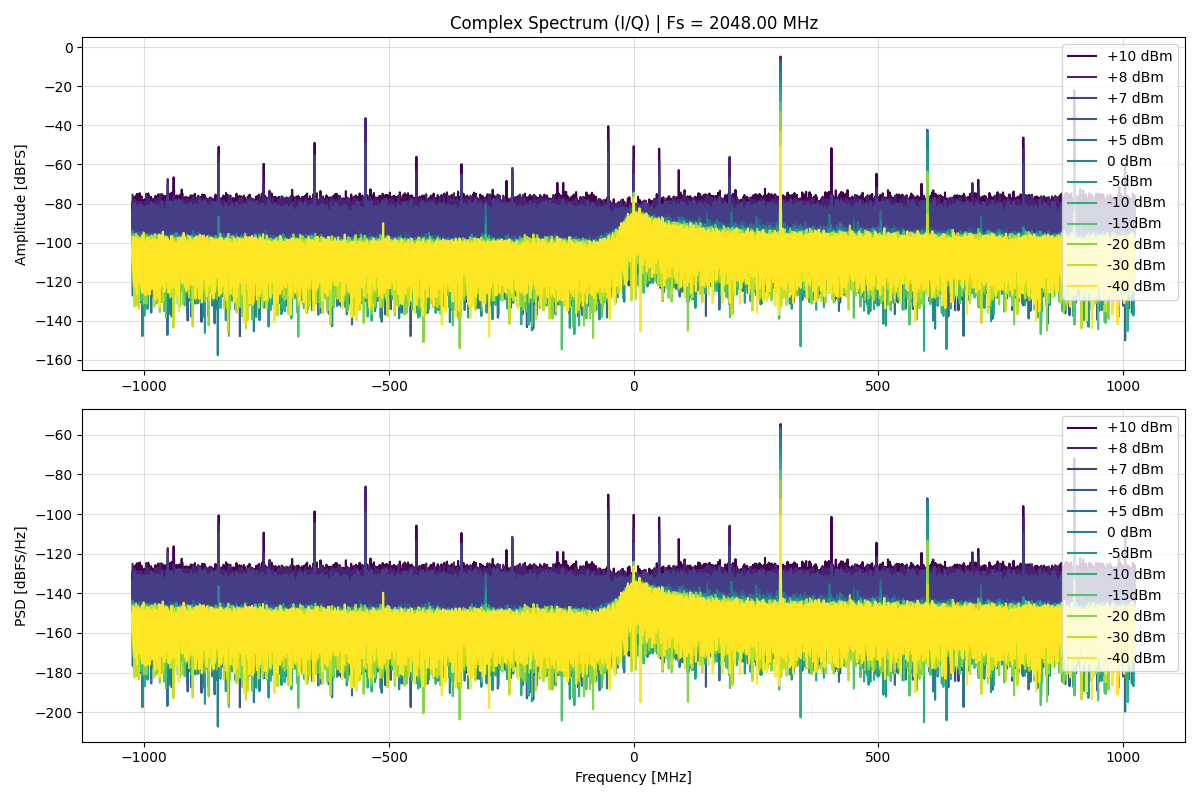

+10 dBm: Peak = -4.84 dBFS, Peak linear = 18778.371
+8 dBm: Peak = -5.42 dBFS, Peak linear = 17553.455
+7 dBm: Peak = -5.91 dBFS, Peak linear = 16585.461
+6 dBm: Peak = -6.82 dBFS, Peak linear = 14934.915
+5 dBm: Peak = -7.83 dBFS, Peak linear = 13306.470
0 dBm: Peak = -12.84 dBFS, Peak linear = 7473.370
-5dBm: Peak = -17.85 dBFS, Peak linear = 4198.245
-10 dBm: Peak = -22.83 dBFS, Peak linear = 2365.365
-15dBm: Peak = -27.97 dBFS, Peak linear = 1309.679
-20 dBm: Peak = -32.93 dBFS, Peak linear = 739.353
-30 dBm: Peak = -42.89 dBFS, Peak linear = 234.929
-40 dBm: Peak = -50.79 dBFS, Peak linear = 94.578


In [120]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# List of file paths and labels
file_paths = [
    'data/f_300+10dBm/x_adc_t_data.txt',
    'data/f_300+8dBm/x_adc_t_data.txt',
    'data/f_300+7dBm/x_adc_t_data.txt',
    'data/f_300+6dBm/x_adc_t_data.txt',
    'data/f_300+5dBm/x_adc_t_data.txt',
    'data/f_300-0dBm/x_adc_t_data.txt',
    'data/f_300-5dBm/x_adc_t_data.txt',
    'data/f_300-10dBm/x_adc_t_data.txt',
    'data/f_300-15dBm/x_adc_t_data.txt',
    'data/f_300-20dBm/x_adc_t_data.txt',
    'data/f_300-30dBm/x_adc_t_data.txt',
    'data/f_300-40dBm/x_adc_t_data.txt'
]
labels_list = ['+10 dBm','+8 dBm','+7 dBm','+6 dBm','+5 dBm','0 dBm', '-5dBm','-10 dBm', '-15dBm','-20 dBm', '-30 dBm', '-40 dBm']

# Prepare colors
colors = plt.cm.viridis(np.linspace(0, 1, len(file_paths)))

plt.figure(figsize=(12, 8))

# --- Process each measurement ---
for i, file_path in enumerate(file_paths):
    # Load complex data
    x_adc_t = np.loadtxt(file_path, dtype=np.complex128)

    N = len(x_adc_t)

    # --- 1. Window Processing ---
    window = np.hanning(N)
    x_windowed = x_adc_t * window

    # --- 2. Complex FFT ---
    fft_complex = np.fft.fft(x_windowed) / N
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))

    # --- 3. Amplitude in dBFS ---
    mag_linear = np.abs(fft_complex) / 0.5  # Correct for Hanning CG
    with np.errstate(divide='ignore'):
        mag_dbfs = 20 * np.log10(mag_linear / FS)

    # --- 4. PSD ---
    enbw_hz = 1.5 * (Fs / N)
    psd_dbfs_hz = mag_dbfs - 10 * np.log10(enbw_hz)

    # --- 5. Plot amplitude ---
    plt.subplot(2, 1, 1)
    plt.plot(freqs / 1e6, mag_dbfs, color=colors[i], label=labels_list[i])

    # --- 6. Plot PSD ---
    plt.subplot(2, 1, 2)
    plt.plot(freqs / 1e6, psd_dbfs_hz, color=colors[i], label=labels_list[i])

# --- Finalize Amplitude plot ---
plt.subplot(2, 1, 1)
plt.title(f"Complex Spectrum (I/Q) | Fs = {Fs/1e6:.2f} MHz")
plt.ylabel("Amplitude [dBFS]")
plt.grid(True, alpha=0.4)
plt.ylim([None, 5])
plt.legend()

# --- Finalize PSD plot ---
plt.subplot(2, 1, 2)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD [dBFS/Hz]")
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

# --- Print peak info for each measurement ---
for i, file_path in enumerate(file_paths):
    x_adc_t = np.loadtxt(file_path, dtype=np.complex128)
    N = len(x_adc_t)
    window = np.hanning(N)
    x_windowed = x_adc_t * window
    fft_complex = np.fft.fft(x_windowed) / N
    mag_linear = np.abs(fft_complex) / 0.5
    mag_dbfs = 20 * np.log10(mag_linear / FS)
    peak_idx = np.argmax(mag_dbfs)
    print(f"{labels_list[i]}: Peak = {mag_dbfs[peak_idx]:.2f} dBFS, Peak linear = {mag_linear[peak_idx]:.3f}")

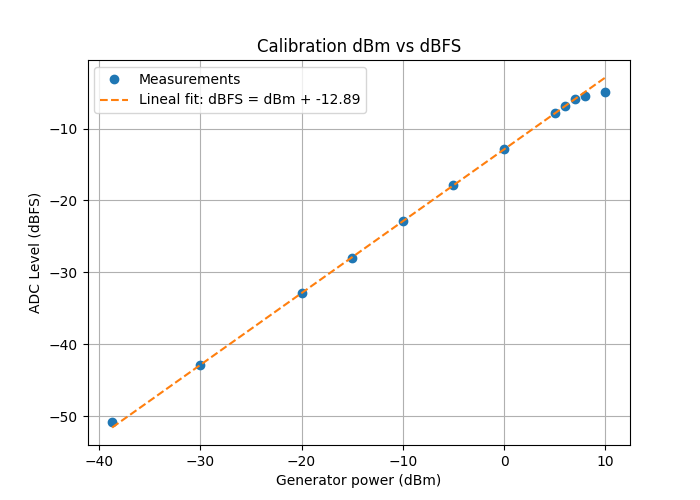

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Measured data
P_dBm = np.array([-38.7,-30, -20, -15, -10, -5, 0, +5, +6, +7, +8, +10])          # Generator power in dBm. -38.7 measured (-40dBm)
dBFS_measured = np.array([-50.79,-42.89,-32.93, -27.97, -22.83, -17.85, -12.84, -7.83,-6.82, -5.91, -5.42, -4.84])  # Pico FFT medido en dBFS

# Ajuste lineal (dBFS = P_dBm + K)
K = dBFS_measured[1] - P_dBm[1]  # Constante de calibración
dBFS_fit = P_dBm + K

# Graficar
plt.figure(figsize=(7,5))
plt.plot(P_dBm, dBFS_measured, 'o', label='Measurements')
plt.plot(P_dBm, dBFS_fit, '--', label=f'Lineal fit: dBFS = dBm + {K:.2f}')
plt.xlabel('Generator power (dBm)')
plt.ylabel('ADC Level (dBFS)')
plt.title('Calibration dBm vs dBFS')
plt.grid(True)
plt.legend()
plt.show()

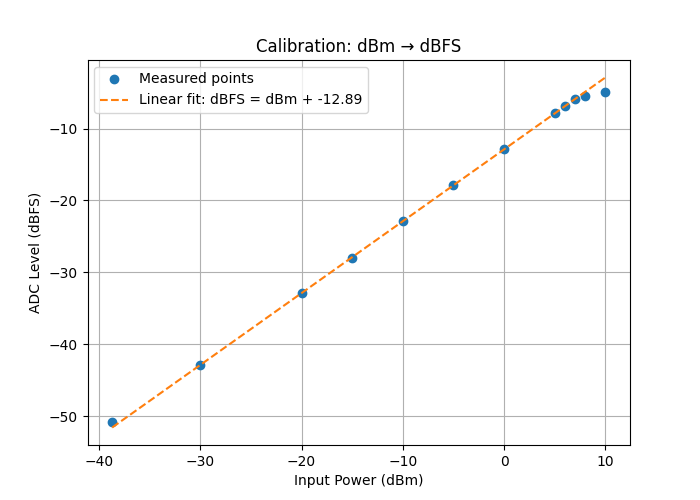

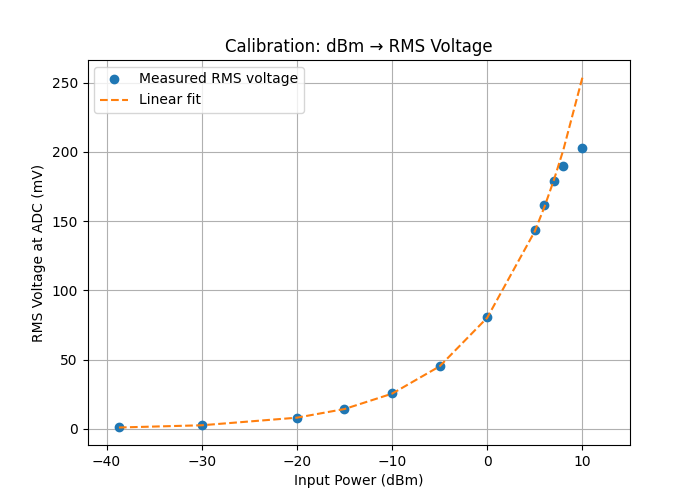

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Measured data
P_dBm = np.array([-38.7,-30, -20, -15, -10, -5, 0, +5, +6, +7, +8, +10])          # Generator power in dBm. -38.7 measured (-40dBm)
dBFS_measured = np.array([-50.79,-42.89,-32.93, -27.97, -22.83, -17.85, -12.84, -7.83,-6.82, -5.91, -5.42, -4.84])  # Pico FFT medido en dBFS

# Calibration constant (linear relation: dBFS = P_dBm + K)
K = dBFS_measured[1] - P_dBm[1]  # ~-12.83 dB
dBFS_fit = P_dBm + K

# ADC full-scale RMS voltage
V_FS_RMS = 0.354  # V RMS for differential input

# Convert dBFS to RMS voltage
V_RMS_measured = V_FS_RMS * 10**(dBFS_measured/20)
V_RMS_fit = V_FS_RMS * 10**(dBFS_fit/20)

# Plot 1: Generator power vs ADC level in dBFS
plt.figure(figsize=(7,5))
plt.plot(P_dBm, dBFS_measured, 'o', label='Measured points')
plt.plot(P_dBm, dBFS_fit, '--', label=f'Linear fit: dBFS = dBm + {K:.2f}')
plt.xlabel('Input Power (dBm)')
plt.ylabel('ADC Level (dBFS)')
plt.title('Calibration: dBm → dBFS')
plt.grid(True)
plt.legend()
plt.show()
plt.savefig('images/ADC_calibration_111_dBm_to_Pin.png',dpi=300)

# Plot 2: Generator power vs ADC RMS voltage
plt.figure(figsize=(7,5))
plt.plot(P_dBm, V_RMS_measured*1e3, 'o', label='Measured RMS voltage')
plt.plot(P_dBm, V_RMS_fit*1e3, '--', label='Linear fit')
plt.xlabel('Input Power (dBm)')
plt.ylabel('RMS Voltage at ADC (mV)')
plt.title('Calibration: dBm → RMS Voltage')
plt.grid(True)
plt.legend()
plt.xlim(-42,15)
plt.show()
plt.savefig('images/ADC_calibration_111_dBm_to_RMSin.png',dpi=300)

In [75]:
x_adc_t = np.loadtxt('data/f_300-20dBm/x_adc_t_data.txt', dtype=np.complex128)
xi = x_adc_t.real
xq = x_adc_t.imag

Mean value of real comp.: -0.18 LSB
Mean value of imag comp.: -0.27 LSB


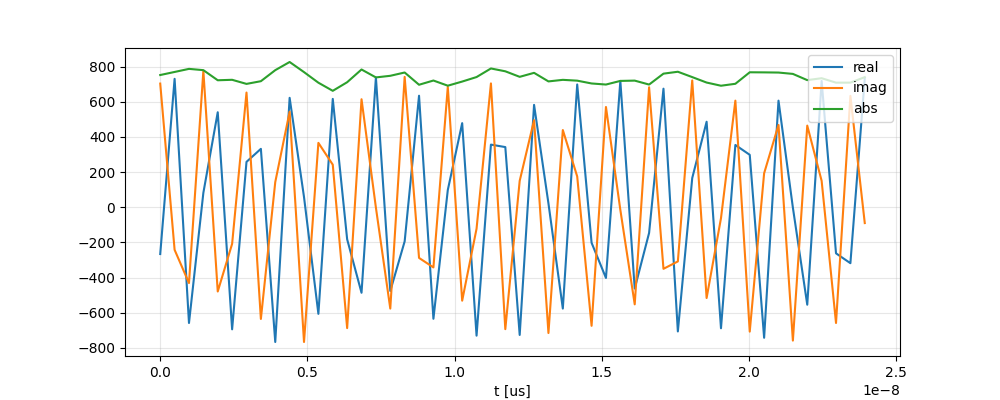

In [76]:
nsamp = 50
plt.figure(figsize=(10,4))
t = np.arange(len(x_adc_t))/Fs
plt.plot(t[:nsamp],xi[:nsamp],label='real')
plt.plot(t[:nsamp],xq[:nsamp],label='imag')
plt.plot(t[:nsamp],np.abs(x_adc_t[:nsamp]),label='abs')
plt.xlabel("t [us]")
plt.legend(loc='upper right') 
plt.grid(True, alpha=0.3)

print(f"Mean value of real comp.: {np.mean(xi):.2f} LSB")
print(f"Mean value of imag comp.: {np.mean(xq):.2f} LSB")

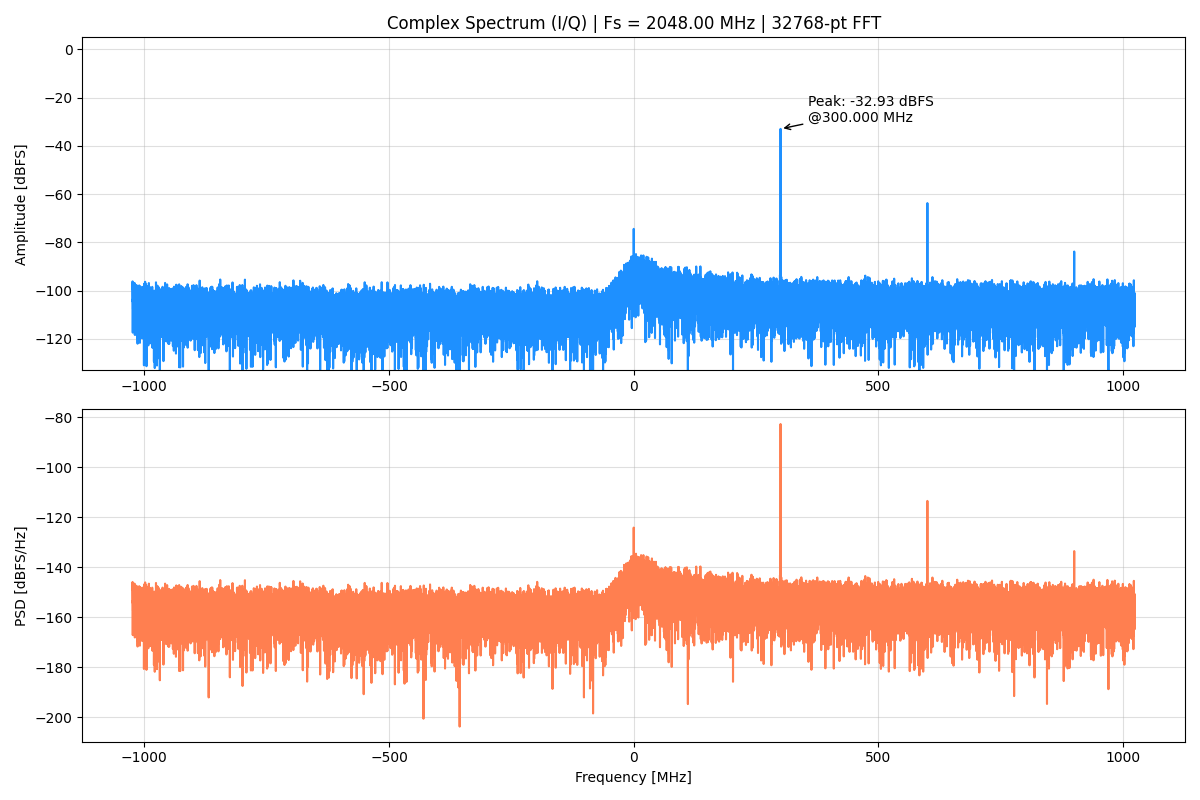

Calculated Tone: -32.93 dBFS
Average Noise Density: -155.14 dBFS/Hz
Peak linear amplitude: 739.35
868.9861909144471


In [77]:
import numpy as np
import matplotlib.pyplot as plt

# x_adc_t = real_part + 1j * imag_part 
N = len(x_adc_t)

# --- 1. Window Processing ---
# A Hanning window reduces the tone's amplitude in the frequency domain.
# To recover the true amplitude, we divide by the Coherent Gain (0.5 for Hanning).
window = np.hanning(N)
x_windowed = x_adc_t * window

# --- 2. Complex FFT ---
# Standardize by N to reverse FFT processing gain.
# Note: For complex (I/Q) data, the FFT peak directly represents 
# the full amplitude of the complex phasor.
fft_complex = np.fft.fft(x_windowed) / N
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))
    
# --- 3. Amplitude in dBFS ---
# Correct the linear magnitude using the Window Coherent Gain (0.5)
mag_linear = np.abs(fft_complex) / 0.5

# Convert to dBFS (decibels relative to Full Scale)
# We use our previously defined FS = 32768 (16-bit MSB-aligned)
with np.errstate(divide='ignore'):
    mag_dbfs = 20 * np.log10(mag_linear / FS)

# --- 4. PSD Calculation (dBFS/Hz) ---
# ENBW for Hanning is 1.5 bins. We convert this to Hz.
# PSD (dB/Hz) = Power_per_bin (dB) - 10*log10(Bin_Width_in_Hz * Window_Correction)
enbw_hz = 1.5 * (Fs / N) 
psd_dbfs_hz = mag_dbfs - 10 * np.log10(enbw_hz)

# --- 5. Plotting ---
plt.figure(figsize=(12, 8))

# Subplot 1: Amplitude Spectrum
plt.subplot(2, 1, 1)
plt.plot(freqs / 1e6, mag_dbfs, color='dodgerblue')
plt.title(f"Complex Spectrum (I/Q) | Fs = {Fs/1e6:.2f} MHz | {N}-pt FFT")
plt.ylabel("Amplitude [dBFS]")
plt.grid(True, alpha=0.4)
# Focus view: from peak down to 100dB below
plt.ylim([np.max(mag_dbfs)-100, 5]) 

# Peak Annotation
peak_idx = np.argmax(mag_dbfs)
plt.annotate(f'Peak: {mag_dbfs[peak_idx]:.2f} dBFS\n@{freqs[peak_idx]/1e6:.3f} MHz', 
             xy=(freqs[peak_idx]/1e6, mag_dbfs[peak_idx]), 
             xytext=(20, 5), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

# Subplot 2: Power Spectral Density
plt.subplot(2, 1, 2)
plt.plot(freqs / 1e6, psd_dbfs_hz, color='coral')
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD [dBFS/Hz]")
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Calculated Tone: {mag_dbfs[peak_idx]:.2f} dBFS")
print(f"Average Noise Density: {np.median(psd_dbfs_hz):.2f} dBFS/Hz")
print(f"Peak linear amplitude: {mag_linear[peak_idx]:.2f}")
print(np.max(np.abs(x_adc_t)))

In [72]:
#Now data with 0dBm
x_adc_t = np.loadtxt('data/f_300-10dBm/x_adc_t_data.txt', dtype=np.complex128)
xi = x_adc_t.real
xq = x_adc_t.imag

Mean value of real comp.: 0.14 LSB
Mean value of imag comp.: -0.12 LSB


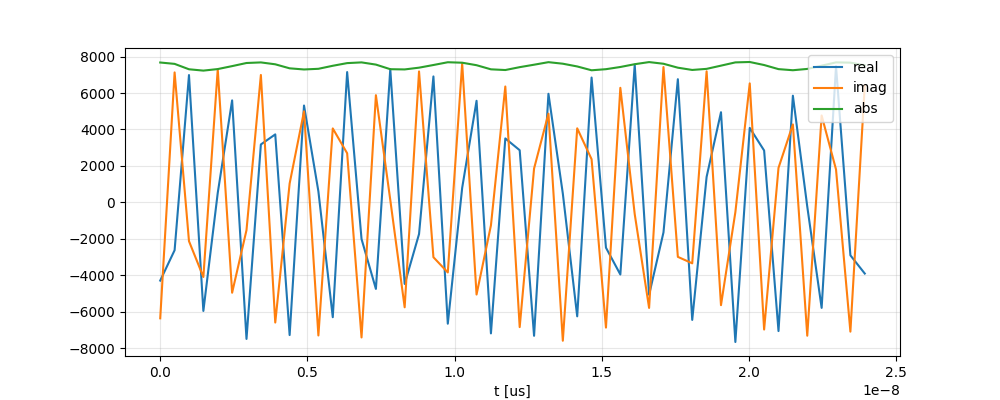

In [73]:
nsamp = 50
plt.figure(figsize=(10,4))
t = np.arange(len(x_adc_t))/Fs
plt.plot(t[:nsamp],xi[:nsamp],label='real')
plt.plot(t[:nsamp],xq[:nsamp],label='imag')
plt.plot(t[:nsamp],np.abs(x_adc_t[:nsamp]),label='abs')
plt.xlabel("t [us]")
plt.legend(loc='upper right') 
plt.grid(True, alpha=0.3)

print(f"Mean value of real comp.: {np.mean(xi):.2f} LSB")
print(f"Mean value of imag comp.: {np.mean(xq):.2f} LSB")

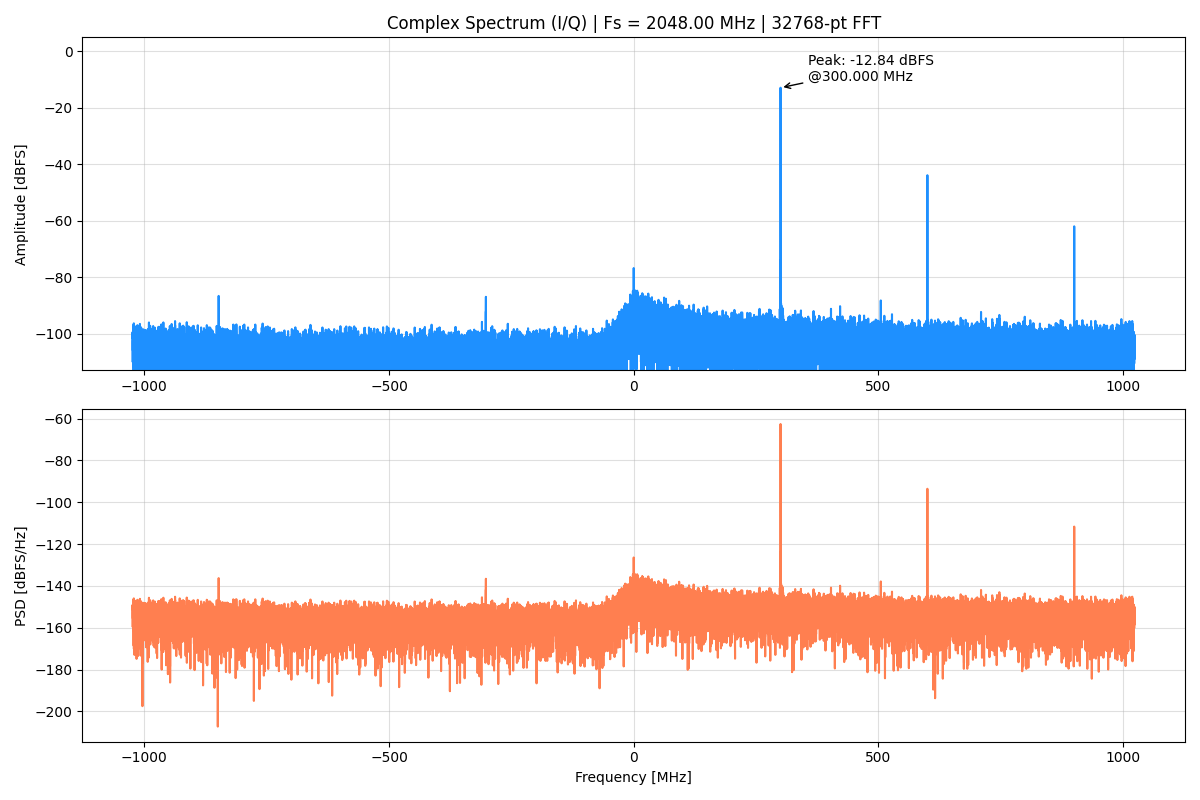

Calculated Tone: -12.84 dBFS
Average Noise Density: -154.63 dBFS/Hz
Peak linear amplitude: 7473.37
7774.442037857122


In [74]:
import numpy as np
import matplotlib.pyplot as plt

# x_adc_t = real_part + 1j * imag_part 
N = len(x_adc_t)

# --- 1. Window Processing ---
# A Hanning window reduces the tone's amplitude in the frequency domain.
# To recover the true amplitude, we divide by the Coherent Gain (0.5 for Hanning).
window = np.hanning(N)
x_windowed = x_adc_t * window

# --- 2. Complex FFT ---
# Standardize by N to reverse FFT processing gain.
# Note: For complex (I/Q) data, the FFT peak directly represents 
# the full amplitude of the complex phasor.
fft_complex = np.fft.fft(x_windowed) / N
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))
    
# --- 3. Amplitude in dBFS ---
# Correct the linear magnitude using the Window Coherent Gain (0.5)
mag_linear = np.abs(fft_complex) / 0.5

# Convert to dBFS (decibels relative to Full Scale)
# We use our previously defined FS = 32768 (16-bit MSB-aligned)
with np.errstate(divide='ignore'):
    mag_dbfs = 20 * np.log10(mag_linear / FS)

# --- 4. PSD Calculation (dBFS/Hz) ---
# ENBW for Hanning is 1.5 bins. We convert this to Hz.
# PSD (dB/Hz) = Power_per_bin (dB) - 10*log10(Bin_Width_in_Hz * Window_Correction)
enbw_hz = 1.5 * (Fs / N) 
psd_dbfs_hz = mag_dbfs - 10 * np.log10(enbw_hz)

# --- 5. Plotting ---
plt.figure(figsize=(12, 8))

# Subplot 1: Amplitude Spectrum
plt.subplot(2, 1, 1)
plt.plot(freqs / 1e6, mag_dbfs, color='dodgerblue')
plt.title(f"Complex Spectrum (I/Q) | Fs = {Fs/1e6:.2f} MHz | {N}-pt FFT")
plt.ylabel("Amplitude [dBFS]")
plt.grid(True, alpha=0.4)
# Focus view: from peak down to 100dB below
plt.ylim([np.max(mag_dbfs)-100, 5]) 

# Peak Annotation
peak_idx = np.argmax(mag_dbfs)
plt.annotate(f'Peak: {mag_dbfs[peak_idx]:.2f} dBFS\n@{freqs[peak_idx]/1e6:.3f} MHz', 
             xy=(freqs[peak_idx]/1e6, mag_dbfs[peak_idx]), 
             xytext=(20, 5), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

# Subplot 2: Power Spectral Density
plt.subplot(2, 1, 2)
plt.plot(freqs / 1e6, psd_dbfs_hz, color='coral')
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD [dBFS/Hz]")
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Calculated Tone: {mag_dbfs[peak_idx]:.2f} dBFS")
print(f"Average Noise Density: {np.median(psd_dbfs_hz):.2f} dBFS/Hz")
print(f"Peak linear amplitude: {mag_linear[peak_idx]:.2f}")
print(np.max(np.abs(x_adc_t)))

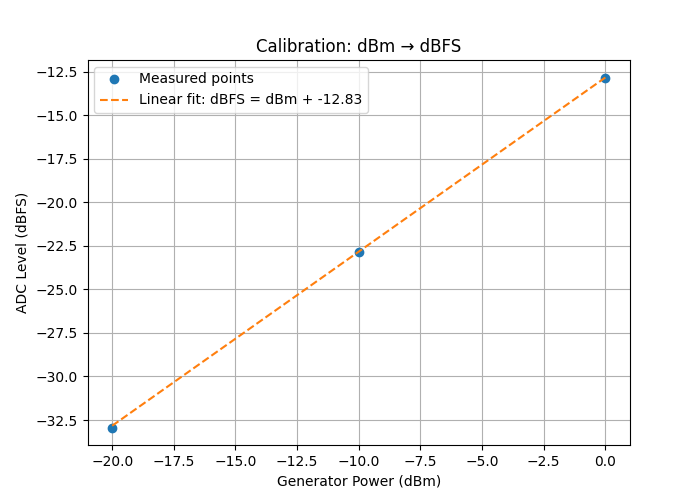

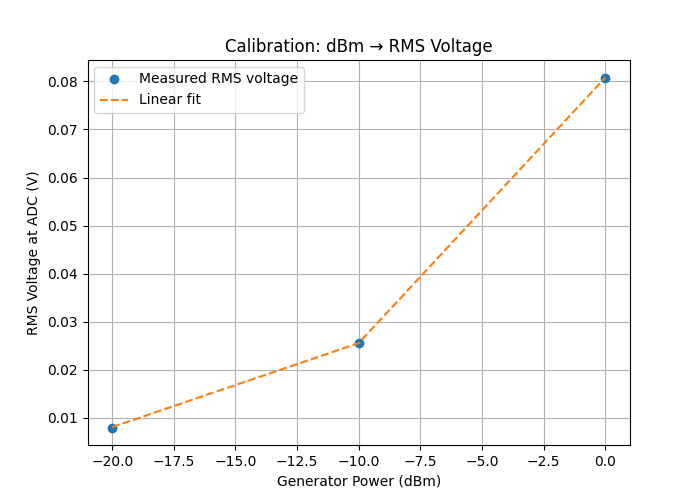

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Measured data
P_dBm = np.array([-20, -10, 0])          # Generator power in dBm
dBFS_measured = np.array([-32.93, -22.83, -12.84])  # Measured ADC peak FFT in dBFS

# Calibration constant (linear relation: dBFS = P_dBm + K)
K = dBFS_measured[1] - P_dBm[1]  # ~-12.83 dB
dBFS_fit = P_dBm + K

# ADC full-scale RMS voltage
V_FS_RMS = 0.354  # V RMS for differential input

# Convert dBFS to RMS voltage
V_RMS_measured = V_FS_RMS * 10**(dBFS_measured/20)
V_RMS_fit = V_FS_RMS * 10**(dBFS_fit/20)

# Plot 1: Generator power vs ADC level in dBFS
plt.figure(figsize=(7,5))
plt.plot(P_dBm, dBFS_measured, 'o', label='Measured points')
plt.plot(P_dBm, dBFS_fit, '--', label=f'Linear fit: dBFS = dBm + {K:.2f}')
plt.xlabel('Generator Power (dBm)')
plt.ylabel('ADC Level (dBFS)')
plt.title('Calibration: dBm → dBFS')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Generator power vs ADC RMS voltage
plt.figure(figsize=(7,5))
plt.plot(P_dBm, V_RMS_measured, 'o', label='Measured RMS voltage')
plt.plot(P_dBm, V_RMS_fit, '--', label='Linear fit')
plt.xlabel('Generator Power (dBm)')
plt.ylabel('RMS Voltage at ADC (V)')
plt.title('Calibration: dBm → RMS Voltage')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load ADC time data
# -----------------------------
V = np.loadtxt("data/f_300/x_adc_t_data.txt")

# -----------------------------
# Recover FFT magnitude
# -----------------------------
# |X[k]| = sqrt(P[k])
X_mag = np.sqrt(P)

# -----------------------------
# Recover real tone amplitude
# -----------------------------
# Since FFT is unscaled:
# |X[k0]| = N * A
# A = |X[k0]| / N
A = X_mag / N

# -----------------------------
# Normalize to Full-Scale
# -----------------------------
A_FS = A / FS

# Convert to dBFS
A_dBFS = 20 * np.log10(A_FS + 1e-20)

# -----------------------------
# Frequency Axis
# -----------------------------
# Spectrum is already centered (tone at DC)
freq = np.linspace(-Fs/2, Fs/2, N)

# -----------------------------
# Plot Amplitude Spectrum
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq, A_dBFS)
plt.title("Amplitude Spectrum (dBFS)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dBFS)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Notebook Section 2 — Mathematical Background

## (1) What does the FFT compute?

Since the FFT is unscaled:

$$
\begin{equation}
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi kn/N}
\end{equation}
$$

For a coherent complex tone (tone whose frequency is exactly aligned with a bin of the FFT):

$$
\begin{equation}
|X[k_0]| = N \cdot A
\end{equation}
$$

Where:

* $( A )$ = actual tone amplitude in ADC LSB units.

Therefore:

$$
\begin{equation}
A = \frac{|X[k_0]|}{N}
\end{equation}
$$

---

## (2) What does the IP give us?
The IP (FFT + Accumulator) gives:

$$
\begin{equation}
P[k] = |X[k]|^2
\end{equation}
$$

So:

$$
\begin{equation}
|X[k]| = \sqrt{P[k]}
\end{equation}
$$

Therefore:

$$
\begin{equation}
A = \frac{\sqrt{P[k]}}{N}
\end{equation}
$$

---

## (3) Convert to dBFS

Full-scale amplitude:

$$
\begin{equation}
FS = 2^{15} = 32768
\end{equation}
$$

Normalized amplitude:

$$
\begin{equation}
A_{FS} = \frac{A}{FS}
\end{equation}
$$

Amplitude in dBFS:

$$
\begin{equation}
20\log_{10}(A_{FS})
\end{equation}
$$

Expected value for half-scale tone:

$$
\begin{equation}
20\log_{10}(0.5) = -6.02 \text{ dBFS}
\end{equation}
$$

---
# Notebook Section 3 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# System Parameters
# -----------------------------
Fs = 32e6               # Sampling frequency
N = 65536               # FFT size
N_bits = 14             # ADC resolution
FS = 2**(N_bits - 1)    # Full-scale amplitude (8192)

# -----------------------------
# Load FFT power data
# -----------------------------
# P[k] = averaged |X[k]|^2
P = np.loadtxt("data/fft_spectrum_data.txt")

# -----------------------------
# Recover FFT magnitude
# -----------------------------
# |X[k]| = sqrt(P[k])
X_mag = np.sqrt(P)

# -----------------------------
# Recover real tone amplitude
# -----------------------------
# Since FFT is unscaled:
# |X[k0]| = N * A
# A = |X[k0]| / N
A = X_mag / N

# -----------------------------
# Normalize to Full-Scale
# -----------------------------
A_FS = A / FS

# Convert to dBFS
A_dBFS = 20 * np.log10(A_FS + 1e-20)

# -----------------------------
# Frequency Axis
# -----------------------------
# Spectrum is already centered (tone at DC)
freq = np.linspace(-Fs/2, Fs/2, N)

# -----------------------------
# Plot Amplitude Spectrum
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq, A_dBFS)
plt.title("Amplitude Spectrum (dBFS)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dBFS)")
plt.grid(True)
plt.tight_layout()
plt.show()

FileNotFoundError: data/fft_spectrum_data.txt not found.

---

# Notebook Section 4 — PSD Derivation

Now the correct PSD derivation.

---

## (1) True signal power

Since:

$$
\begin{equation}
|X[k]| = N A
\end{equation}
$$

Then:

$$
\begin{equation}
|X[k]|^2 = N^2 A^2
\end{equation}
$$

To recover actual signal power:

$$
\begin{equation}
A^2 = \frac{P[k]}{N^2}
\end{equation}
$$

---

## (2) Convert to Power Spectral Density

Each FFT bin represents:

$$
\begin{equation}
\Delta f = \frac{Fs}{N}
\end{equation}
$$

So PSD is:

$$
\begin{equation}
PSD[k] = \frac{A^2}{\Delta f}
\end{equation}
$$

Combining:

$$
\begin{equation}
PSD[k] = \frac{P[k]}{N^2 \Delta f}
\end{equation}
$$

---

## (3) Convert to dBFS/Hz

Normalize power to $\text{FS}^2$:

$$
\begin{equation}
PSD_{FS} = \frac{PSD}{FS^2}
\end{equation}
$$

Then:

$$
\begin{equation}
10\log_{10}(PSD_{FS})
\end{equation}
$$

---

# Notebook Section 5 — PSD Code

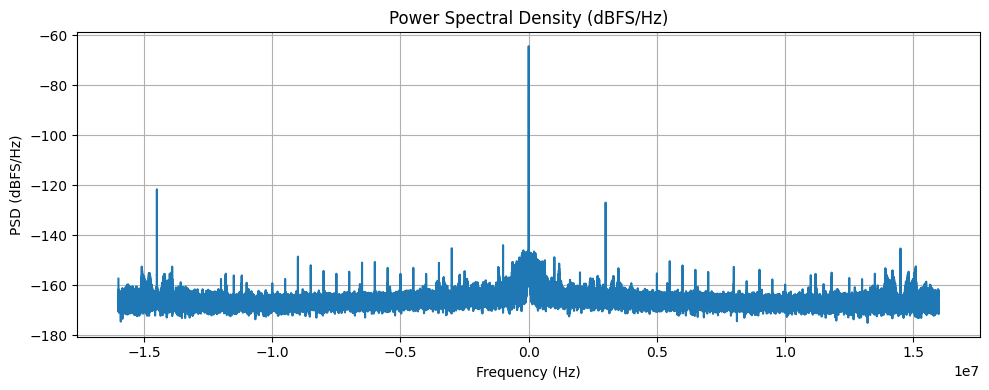

In [6]:
# -----------------------------
# Frequency resolution
# -----------------------------
df = Fs / N

# -----------------------------
# True power per bin
# -----------------------------
# A^2 = P / N^2
# PSD = A^2 / df
PSD = P / (N**2 * df)

# Normalize to FS power
PSD_FS = PSD / (FS**2)

PSD_dBFS_per_Hz = 10 * np.log10(PSD_FS + 1e-20)

# -----------------------------
# Plot PSD
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq, PSD_dBFS_per_Hz)
plt.title("Power Spectral Density (dBFS/Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dBFS/Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()

---

# Final Summary

---

### Why divide by N?

Because the FFT is unscaled:

$$
\begin{equation}
X[k] = \sum x[n]
\end{equation}
$$

So coherent tones grow proportionally to $N$.

---

### Why divide by $N^2$ in PSD?

Because:

$$
\begin{equation}
|X|^2 = N^2 A^2
\end{equation}
$$

We must remove FFT gain before computing physical power.

---

### Why $20\log_{10}$ for amplitude and $10\log_{10}$ for PSD?

Because:

* Amplitude is proportional to voltage $\rightarrow 20\log_{10}$
* PSD is power $\rightarrow 10\log_{10}$

---

# What this notebook now guarantees

* Correct amplitude recovery
* Correct dBFS normalization
* Correct PSD scaling
* Physically interpretable results
* Direct comparison against expected $-6.02\,\text{dBFS}$ tone

---

# Extras

ADC value 1000 corresponds to 3.77 dBm


ADC value 1000 corresponds to 3.77 dBm
